In [5]:
# импорт необходимых библиотек
import numpy as np
import pandas as pd
import re
import nltk
import string
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
# читаем данные из CSV-файла
df = pd.read_csv('reviews.csv', encoding='utf-8', sep='\t')
df.head() # вывод первых 5 строк из датафрейма


,review,sentiment
0,качество плохое пошив ужасный (горловина напер...,negative
1,"Товар отдали другому человеку, я не получила п...",negative
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative
3,"товар не пришел, продавец продлил защиту без м...",negative
4,"Кофточка голая синтетика, носить не возможно.",negative


In [7]:
# предобработка текста
# ЭТАП 1 - ПРИВЕДЕНИЕ К НИЖНЕМУ РЕГИСТРУ
# создадим отдельную колонку cleaned_reviews для обработанного текста

df['cleaned_reviews'] = df['review'].str.lower()
df.head()


,review,sentiment,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,negative,качество плохое пошив ужасный (горловина напер...
1,"Товар отдали другому человеку, я не получила п...",negative,"товар отдали другому человеку, я не получила п..."
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,"ужасная синтетика! тонкая, ничего общего с пре..."
3,"товар не пришел, продавец продлил защиту без м...",negative,"товар не пришел, продавец продлил защиту без м..."
4,"Кофточка голая синтетика, носить не возможно.",negative,"кофточка голая синтетика, носить не возможно."


In [8]:
# ЭТАП 2 - удаление пунктуации
df['cleaned_reviews'] = df['cleaned_reviews'].str.replace(r'[^\w\s]','', regex=True)
df.head()

,review,sentiment,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,negative,качество плохое пошив ужасный горловина напере...
1,"Товар отдали другому человеку, я не получила п...",negative,товар отдали другому человеку я не получила по...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая ничего общего с предс...
3,"товар не пришел, продавец продлил защиту без м...",negative,товар не пришел продавец продлил защиту без мо...
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить не возможно


In [9]:
# ЭТАП 3 - удаление стоп-слов
from nltk.corpus import stopwords # импортирn стоп-слов из библиотеки nltk
print(stopwords.words('russian'))


['и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг', 'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был', 'него', 'до', 'вас', 'нибудь', 'опять', 'уж', 'вам', 'ведь', 'там', 'потом', 'себя', 'ничего', 'ей', 'может', 'они', 'тут', 'где', 'есть', 'надо', 'ней', 'для', 'мы', 'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто', 'чего', 'раз', 'тоже', 'себе', 'под', 'будет', 'ж', 'тогда', 'кто', 'этот', 'того', 'потому', 'этого', 'какой', 'совсем', 'ним', 'здесь', 'этом', 'один', 'почти', 'мой', 'тем', 'чтобы', 'нее', 'сейчас', 'были', 'куда', 'зачем', 'всех', 'никогда', 'можно', 'при', 'наконец', 'два', 'об', 'другой', 'хоть', 'после', 'над', 'больше', 'тот', 'через', 'эти', 'нас', 'про', 'всего', 'них', 'какая', 'много', 'разве', 'три', 'эту', 'моя', 'впр

In [10]:
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('russian'))
# функция, удаляющая стоп-слова из текстов

def stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])
# применим функцию удаления стоп-слов
df["cleaned_reviews"] = df["cleaned_reviews"].apply(stopwords)
df.head()

,review,sentiment,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,negative,качество плохое пошив ужасный горловина напере...
1,"Товар отдали другому человеку, я не получила п...",negative,товар отдали другому человеку получила посылку...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...
3,"товар не пришел, продавец продлил защиту без м...",negative,товар пришел продавец продлил защиту моего сог...
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно


In [11]:
# ЭТАП 4 - удаление высокочастотных слов
from collections import Counter
cnt = Counter()
for text in df["cleaned_reviews"].values:
    for word in text.split():
        cnt[word] += 1
        
cnt.most_common(20)

[('очень', 27787),
 ('размер', 19025),
 ('товар', 12791),
 ('качество', 12247),
 ('деньги', 11949),
 ('продавец', 11905),
 ('это', 8329),
 ('заказ', 7708),
 ('доставка', 7676),
 ('ткань', 6786),
 ('спор', 6449),
 ('вернули', 6297),
 ('платье', 6296),
 ('заказала', 6215),
 ('соответствует', 6063),
 ('спасибо', 6028),
 ('фото', 5772),
 ('рост', 5552),
 ('быстро', 5523),
 ('цвет', 5520)]

In [12]:
# удаление самых частотных слов
freq = set([w for (w, wc) in cnt.most_common(10)])
# функция удаления слов
def freqwords(text):
    return " ".join([word for word in str(text).split() if word not 
in freq])
# применение функции
df["cleaned_reviews"] = df["cleaned_reviews"].apply(freqwords)
df.head()

,review,sentiment,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,negative,плохое пошив ужасный горловина наперекос фото ...
1,"Товар отдали другому человеку, я не получила п...",negative,отдали другому человеку получила посылку ладно...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...
3,"товар не пришел, продавец продлил защиту без м...",negative,пришел продлил защиту моего согласия продавца ...
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно


In [13]:
# ЭТАП 5 - удаление низкочастотных слов
freq = pd.Series(' '.join(df['cleaned_reviews']).split()).value_counts()[-10:] # 10 rare words
freq = list(freq.index)
df['cleaned_reviews'] = df['cleaned_reviews'].apply(lambda x: " ".join(x for x in x.split() if x not in freq))
df.head()

,review,sentiment,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,negative,плохое пошив ужасный горловина наперекос фото ...
1,"Товар отдали другому человеку, я не получила п...",negative,отдали другому человеку получила посылку ладно...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...
3,"товар не пришел, продавец продлил защиту без м...",negative,пришел продлил защиту моего согласия продавца ...
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно


In [14]:
# ЭТАП 6 - удаление эмодзи
def emoji(string):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', string)
#passing the emoji function to 'text_rare'
df['cleaned_reviews'] = df['cleaned_reviews'].apply(emoji)
df.head()

,review,sentiment,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,negative,плохое пошив ужасный горловина наперекос фото ...
1,"Товар отдали другому человеку, я не получила п...",negative,отдали другому человеку получила посылку ладно...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...
3,"товар не пришел, продавец продлил защиту без м...",negative,пришел продлил защиту моего согласия продавца ...
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно


In [15]:
# ЭТАП 7 - удаление цифр
df['cleaned_reviews'] = df['cleaned_reviews'].str.replace(r'\d+', '', regex=True) 
df.head(10)

,review,sentiment,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,negative,плохое пошив ужасный горловина наперекос фото ...
1,"Товар отдали другому человеку, я не получила п...",negative,отдали другому человеку получила посылку ладно...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...
3,"товар не пришел, продавец продлил защиту без м...",negative,пришел продлил защиту моего согласия продавца ...
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно
5,Очень глубокие проймы,negative,глубокие проймы
6,Я недовольна заказом.Я вот одного не понимаю п...,negative,недовольна заказомя одного понимаю почему вниз...
7,"заказала размер s на от 64,об 94,начнем с того...",negative,заказала s об начнем влезть туда могут постоя...
8,Заказ я сделала в июле. С тех пор посылка отсл...,negative,сделала июле тех пор посылка отслеживалась гра...
9,Ужасное качество товара!,negative,ужасное товара


In [16]:
# ЭТАП 8 - удаление ссылок
# Функция для удаления URL
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)
# пример
sample_text = "This is my website, https://www.link.com"
no_url_text = remove_urls(sample_text)
print(no_url_text)

# применим функцию к колонке cleaned_reviews в нашем датафрейме
df['cleaned_reviews'] = df['cleaned_reviews'].apply(remove_urls)

This is my website, 


In [17]:
# ЭТАП 9 - токенизация предобработанного текста
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [18]:
# функция токенизации текста
def tokenize_text(text):
    return nltk.word_tokenize(text)

# сохраним токены (списки слов) в отдельной колонке tokenized_text
df['tokenized_text'] = df['cleaned_reviews'].apply(tokenize_text)
df.head()



,review,sentiment,cleaned_reviews,tokenized_text
0,качество плохое пошив ужасный (горловина напер...,negative,плохое пошив ужасный горловина наперекос фото ...,"[плохое, пошив, ужасный, горловина, наперекос,..."
1,"Товар отдали другому человеку, я не получила п...",negative,отдали другому человеку получила посылку ладно...,"[отдали, другому, человеку, получила, посылку,..."
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...,"[ужасная, синтетика, тонкая, общего, представл..."
3,"товар не пришел, продавец продлил защиту без м...",negative,пришел продлил защиту моего согласия продавца ...,"[пришел, продлил, защиту, моего, согласия, про..."
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно,"[кофточка, голая, синтетика, носить, возможно]"


In [22]:
# ЭТАП 10 - лемматизация
# используем библиотеку pymorphy3
import pymorphy3

# определим анализатор
morph = pymorphy3.MorphAnalyzer()

# функция для лемматизации списка токенов
def lemmatize_tokens(tokens):
    if not isinstance(tokens, list):
        return tokens
    # превращаем каждое слово в начальную форму (лемму)
    return [morph.parse(word)[0].normal_form for word in tokens]

# запишем результат в новый столбец lemmatized_text
df['lemmatized_text'] = df['tokenized_text'].apply(lemmatize_tokens)

# Посмотрим на результат
df.head()


,review,sentiment,cleaned_reviews,tokenized_text,lemmatized_text
0,качество плохое пошив ужасный (горловина напер...,negative,плохое пошив ужасный горловина наперекос фото ...,"[плохое, пошив, ужасный, горловина, наперекос,...","[плохой, пошив, ужасный, горловина, наперекос,..."
1,"Товар отдали другому человеку, я не получила п...",negative,отдали другому человеку получила посылку ладно...,"[отдали, другому, человеку, получила, посылку,...","[отдать, другой, человек, получить, посылка, л..."
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...,"[ужасная, синтетика, тонкая, общего, представл...","[ужасный, синтетик, тонкий, общий, представить..."
3,"товар не пришел, продавец продлил защиту без м...",negative,пришел продлил защиту моего согласия продавца ...,"[пришел, продлил, защиту, моего, согласия, про...","[прийти, продлить, защита, мой, согласие, прод..."
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно,"[кофточка, голая, синтетика, носить, возможно]","[кофточка, голый, синтетик, носить, возможно]"


In [ ]:
# здесь я пробовала осуществить лемматизацию с помощью Mystem, но обработка всего датасета занимала очень много времени
# ЭТАП 10 - лемматизация
# используем библиотеку Mystem
#from pymystem3 import Mystem

#m = Mystem()

# Функция для лемматизации списка токенов
#def lemmatize_list_of_tokens(tokens_list):
    #if not isinstance(tokens_list, list):
        # Если это не список (например, пропущенное значение), возвращаем как есть
        #return tokens_list 
    #lemmatized_tokens = [m.lemmatize(token)[0].strip() for token in tokens_list]
    # Удаляем пустые строки, которые могли появиться
    #return [token for token in lemmatized_tokens if token]

# Применяем функцию к колонке 'tokenized_text'
#df['lemmatized_tokens'] = df['tokenized_text'].apply(lemmatize_list_of_tokens)
#df.head()

In [31]:
# ЭТАП 11 - частотный анализ по положительным и отрицательным отзывам
from nltk import FreqDist #FreqDist - класс для подсчёта статистики распределния слов в тексте
import matplotlib.pyplot as plt

# соберём положительные и отрицательные леммы в отдельные списки
pos_lemmas = [word for tokens in df[df['sentiment'] == 'positive']['lemmatized_text'] for word in tokens]
neg_lemmas = [word for tokens in df[df['sentiment'] == 'negative']['lemmatized_text'] for word in tokens]

# создадим распределения частот
fdist_pos = FreqDist(pos_lemmas)
fdist_neg = FreqDist(neg_lemmas)

print("Топ-10 позитивных слов:", fdist_pos.most_common(10))
print("Уникальные слова (гапаксы):", fdist_pos.hapaxes()[:10])
print("\nТоп-10 негативных слов:", fdist_neg.most_common(10))




Топ-10 позитивных слов: [('хороший', 6335), ('спасибо', 4962), ('продавец', 4647), ('прийти', 4187), ('подойти', 3839), ('отличный', 3837), ('рост', 3310), ('приятный', 3073), ('заказать', 3063), ('быстро', 2948)]
Уникальные слова (гапаксы): ['качественай', 'slim', 'лоск', 'лёнхлопок', 'впечатлениесамо', 'сстоить', 'упаковансильный', 'запачкаться', 'водолазкатолько', 'длиннееа']

Топ-10 негативных слов: [('прийти', 9680), ('вернуть', 7582), ('спор', 5950), ('продавец', 4058), ('заказывать', 3362), ('месяц', 3013), ('открыть', 2991), ('получить', 2867), ('размер', 2691), ('заказать', 2653)]


<Axes: title={'center': 'Топ-30 отрицательных слов'}, xlabel='Samples', ylabel='Counts'>

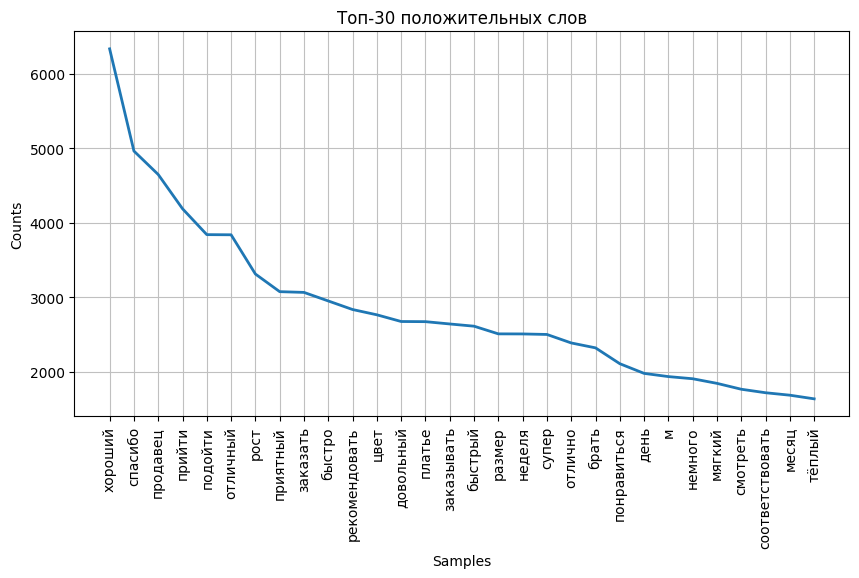

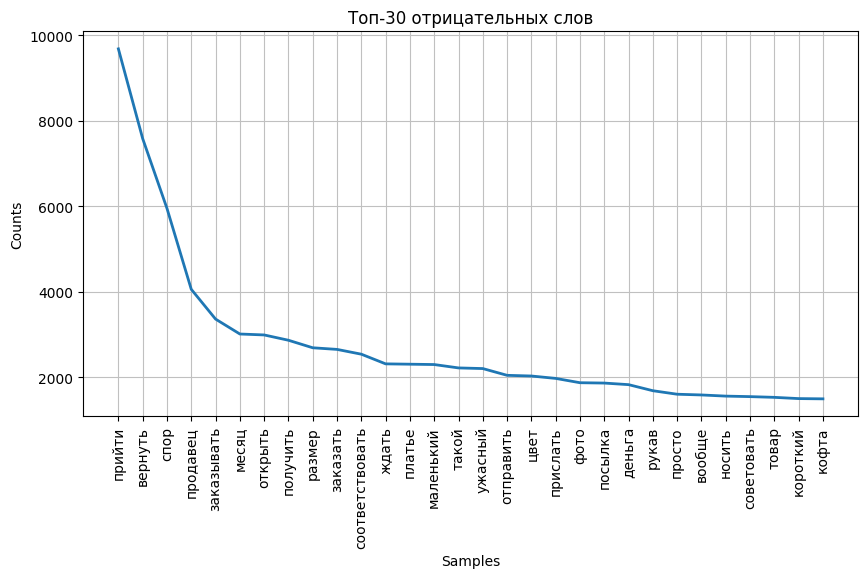

In [ ]:
# ЭТАП 12 - визуализация

# визуализация для положительных слов
plt.figure(figsize=(10, 5))
fdist_pos.plot(30, title='Топ-30 положительных слов', cumulative=False)

# визуализация для негативных слов
plt.figure(figsize=(10, 5))
fdist_neg.plot(30, title='Топ-30 отрицательных слов', cumulative=False)